# Image-to-Text Generation v4 — COCO train2017 (20k) on H100
**Course:** IE 7615 – Deep Learning for AI

## What changed from v3
| Setting | v3 | v4 | Why |
|---|---|---|---|
| Dataset | COCO val2017 (5k images) | **COCO train2017 (20k images)** | 4× more unique images |
| Training pairs | 25,000 | **100,000** | 4× more signal |
| GPU | T4 (15GB) | **H100 (80GB)** | Faster, no OOM risk |
| Batch size | 32 | **64** | H100 handles double batch |
| Accumulation | 2 steps | **1 step** | Not needed on H100 |
| Learning rate | 1e-4 | **2e-4** | Larger batches → higher LR |
| Patience | 3 | **2** | More data converges faster |
| Drive folder | image-captioning-v3/ | **image-captioning-v4/** | Fresh folder |

## What stays the same
- Prefix conditioning (Method A) with 40 prefix tokens
- MLP projection (2-layer + Tanh)
- LoRA rank 16, alpha 32 on c_attn
- Beam search k=5, length penalty 1.2
- GPT-2 base model

## New in v4 — Section 12: Test on your own images
Upload any image or paste a URL — the model generates a caption for it instantly.

## Section 1 — Setup & Google Drive Mount

**Before running:** Runtime → Change runtime type → Select H100 GPU → Save → Restart session.
You should see ~79GB VRAM free after a clean restart.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# v4 — fresh folder, v1/v2/v3 untouched
BASE_DIR    = Path('/content/drive/MyDrive/image-captioning-v4')
DATA_DIR    = BASE_DIR / 'data'
IMAGES_DIR  = DATA_DIR / 'train2017_subset'
ANNOT_DIR   = DATA_DIR / 'annotations'
CKPT_DIR    = BASE_DIR / 'checkpoints'
RESULTS_DIR = BASE_DIR / 'results'

for d in [DATA_DIR, IMAGES_DIR, ANNOT_DIR, CKPT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'v4 base     : {BASE_DIR}')
print(f'Images      : {IMAGES_DIR}')

# Drive space check
import shutil
_, _, free = shutil.disk_usage('/content/drive/MyDrive')
print(f'Drive free  : {free/1e9:.1f} GB  (need at least 6GB for 20k images + checkpoints)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
v4 base     : /content/drive/MyDrive/image-captioning-v4
Images      : /content/drive/MyDrive/image-captioning-v4/data/train2017_subset
Drive free  : 13.2 GB  (need at least 6GB for 20k images + checkpoints)


## Section 2 — Package Installation

In [ ]:
!pip uninstall -y peft transformers accelerate 2>/dev/null
!pip install -q "transformers==4.44.2"
!pip install -q "peft==0.12.0"
!pip install -q "accelerate==0.33.0"
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q pycocoevalcap pycocotools
!pip install -q Pillow matplotlib tqdm requests
print('Done. Runtime → Restart session, then run from imports cell onward.')

Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 29.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 18.1 MB/s eta 0:00:00
   ━

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9

    print(f'GPU Name  : {gpu_name}')
    print(f'VRAM      : {vram_gb:.1f} GB')
    print()

    # Tell you exactly what to do based on what you got
    if 'H100' in gpu_name:
        print('You have H100 — best possible. Run v4 as written.')
        print('Batch size: 64, no accumulation needed.')
    elif 'A100' in gpu_name:
        print('You have A100 — excellent. Run v4 as written.')
        print('Batch size: 64, no accumulation needed.')
    elif 'L4' in gpu_name:
        print('You have L4 — great. Run v4 as written.')
        print('Batch size: 64, no accumulation needed.')
    elif 'T4' in gpu_name:
        print('You have T4 — good. Change batch size to 32, accumulation to 2.')
    elif 'G4' in gpu_name:
        print('You have G4 — not ideal for ML.')
        print('Disconnect and try again: Runtime → Disconnect and delete runtime.')
    else:
        print(f'Unknown GPU: {gpu_name}')
        print(f'Check VRAM — if above 20GB run as written, if below use batch=32.')
else:
    print('No GPU detected — make sure you selected a GPU runtime.')
    print('Runtime → Change runtime type → select a GPU → Save.')

GPU Name  : NVIDIA H100 80GB HBM3
VRAM      : 85.0 GB

You have H100 — best possible. Run v4 as written.
Batch size: 64, no accumulation needed.


In [ ]:
# Run after restarting session
import os, json, random, time, gc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import warnings, requests
warnings.filterwarnings('ignore')

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import clip
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from peft import get_peft_model, LoraConfig, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    free = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()
    print(f'Free   : {free/1e9:.1f} GB')

# Re-declare paths
BASE_DIR    = Path('/content/drive/MyDrive/image-captioning-v4')
DATA_DIR    = BASE_DIR / 'data'
IMAGES_DIR  = DATA_DIR / 'train2017_subset'
ANNOT_DIR   = DATA_DIR / 'annotations'
CKPT_DIR    = BASE_DIR / 'checkpoints'
RESULTS_DIR = BASE_DIR / 'results'
for d in [DATA_DIR, IMAGES_DIR, ANNOT_DIR, CKPT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f'\nBase dir  : {BASE_DIR}')

Device : cuda
GPU    : NVIDIA H100 80GB HBM3
Free   : 85.0 GB

Base dir  : /content/drive/MyDrive/image-captioning-v4


## Section 3 — Data Download

We download COCO train2017 annotations (~1MB) and then download
individual images one by one up to NUM_IMAGES=20,000.

This avoids downloading the full 18GB zip — we only get the images we need (~3.2GB).
If interrupted, re-running skips already-downloaded images automatically.

In [ ]:
import urllib.request, zipfile

# Step 1 — Download train2017 annotations (~1MB)
ANNOT_FILE = ANNOT_DIR / 'captions_train2017.json'

if not ANNOT_FILE.exists():
    print('Downloading COCO train2017 annotations...')
    url      = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
    zip_path = DATA_DIR / 'annotations.zip'
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    # Move annotations to our annot dir
    extracted = DATA_DIR / 'annotations'
    if extracted != ANNOT_DIR:
        import shutil
        for f in extracted.glob('*'):
            shutil.move(str(f), str(ANNOT_DIR / f.name))
    print('Annotations ready.')
else:
    print('Annotations already present.')

# Load annotations and build image_id → captions + filename maps
with open(ANNOT_FILE) as f:
    coco_train = json.load(f)

id_to_captions = {}
for ann in coco_train['annotations']:
    id_to_captions.setdefault(ann['image_id'], []).append(ann['caption'].strip())

id_to_info = {img['id']: img for img in coco_train['images']}

print(f'Total train images in COCO: {len(id_to_info):,}')
print(f'Total annotations         : {len(coco_train["annotations"]):,}')

Annotations ready.
Total train images in COCO: 118,287
Total annotations         : 591,753


In [ ]:
# Step 2 — Download individual images up to NUM_IMAGES
# Images are downloaded from the official COCO CDN one at a time
# Skip any that already exist — safe to re-run after interruption

NUM_IMAGES     = 20000
COCO_IMAGE_URL = 'http://images.cocodataset.org/train2017/'

# Pick first NUM_IMAGES image IDs that have exactly 5 captions
valid_ids = [
    iid for iid, caps in id_to_captions.items()
    if len(caps) == 5 and iid in id_to_info
][:NUM_IMAGES]

print(f'Target images: {len(valid_ids):,}')
already = len(list(IMAGES_DIR.glob('*.jpg')))
print(f'Already downloaded: {already:,}')
print(f'Still needed: {max(0, len(valid_ids) - already):,}')

failed = []
for iid in tqdm(valid_ids, desc='Downloading images'):
    fname    = id_to_info[iid]['file_name']
    out_path = IMAGES_DIR / fname
    if out_path.exists():
        continue
    try:
        urllib.request.urlretrieve(COCO_IMAGE_URL + fname, out_path)
    except Exception:
        failed.append(iid)

downloaded = len(list(IMAGES_DIR.glob('*.jpg')))
print(f'\nImages on disk : {downloaded:,}')
if failed:
    print(f'Failed         : {len(failed)} (will be skipped in pair building)')

import shutil
_, _, free = shutil.disk_usage('/content/drive/MyDrive')
print(f'Drive free now : {free/1e9:.1f} GB')

Target images: 20,000
Already downloaded: 0
Still needed: 20,000



Images on disk : 19,999
Failed         : 1 (will be skipped in pair building)
Drive free now : 8.7 GB


In [ ]:
# Build pair records — 5 captions per image = up to 100k training pairs
pair_records = []
for iid in valid_ids:
    fname    = id_to_info[iid]['file_name']
    captions = id_to_captions[iid]
    if (IMAGES_DIR / fname).exists():
        for cap in captions:
            pair_records.append({
                'image_id'      : iid,
                'filename'      : fname,
                'train_caption' : cap,
                'ref_captions'  : captions
            })

random.shuffle(pair_records)
unique_imgs = len(set(r['image_id'] for r in pair_records))

print(f'Training records : {len(pair_records):,}')
print(f'Unique images    : {unique_imgs:,}')
print(f'Captions/image   : {len(pair_records)/unique_imgs:.1f}')
print(f'\nExample: {pair_records[0]["train_caption"]}')

Training records : 99,995
Unique images    : 19,999
Captions/image   : 5.0

Example: Two small lap dogs in a small bathroom.


## Section 4 — CLIP Embedding Extraction

Extracts one 512-d embedding per unique image and caches to Drive.
20k images takes ~3 minutes on H100. Skipped on re-run if cache exists.

In [ ]:
print('Loading CLIP ViT-B/32...')
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
CLIP_DIM = clip_model.visual.output_dim
print(f'CLIP loaded. Embedding dim: {CLIP_DIM}')

Loading CLIP ViT-B/32...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 141MiB/s]


CLIP loaded. Embedding dim: 512


In [ ]:
EMBED_CACHE_PATH = DATA_DIR / 'clip_embeddings_by_id.pt'

if EMBED_CACHE_PATH.exists():
    print('Loading embedding cache from Drive...')
    embed_cache = torch.load(EMBED_CACHE_PATH)
    print(f'Loaded {len(embed_cache):,} embeddings.')
else:
    unique_records = {r['image_id']: r['filename']
                      for r in pair_records}
    image_ids = list(unique_records.keys())
    filenames  = [unique_records[i] for i in image_ids]

    class UniqueImageDataset(Dataset):
        def __init__(self, filenames, preprocess):
            self.filenames  = filenames
            self.preprocess = preprocess
        def __len__(self): return len(self.filenames)
        def __getitem__(self, idx):
            img = Image.open(IMAGES_DIR / self.filenames[idx]).convert('RGB')
            return self.preprocess(img)

    # H100 can handle larger batch size for extraction
    loader = DataLoader(
        UniqueImageDataset(filenames, clip_preprocess),
        batch_size=256, shuffle=False, num_workers=4, pin_memory=True
    )

    print(f'Extracting CLIP embeddings for {len(image_ids):,} images...')
    all_embeds = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='CLIP encoding'):
            batch = batch.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=True):
                feats = clip_model.encode_image(batch).float()
            feats = feats / feats.norm(dim=-1, keepdim=True)
            all_embeds.append(feats.cpu())

    all_embeds_cat = torch.cat(all_embeds, dim=0)
    embed_cache = {iid: all_embeds_cat[i] for i, iid in enumerate(image_ids)}
    torch.save(embed_cache, EMBED_CACHE_PATH)
    print(f'Saved {len(embed_cache):,} embeddings to Drive.')

print(f'L2 norm check: {next(iter(embed_cache.values())).norm():.4f}  (should be 1.0)')

Extracting CLIP embeddings for 19,999 images...


CLIP encoding:   0%|          | 0/79 [00:00<?, ?it/s]

Saved 19,999 embeddings to Drive.
L2 norm check: 1.0000  (should be 1.0)


## Section 5 — Caption Tokenisation

In [ ]:
MAX_SEQ_LEN = 77
IDS_PATH    = DATA_DIR / 'caption_input_ids.pt'
MASKS_PATH  = DATA_DIR / 'caption_attention_masks.pt'
EMBS_PATH   = DATA_DIR / 'embeddings_aligned.pt'

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
print(f'GPT-2 tokenizer. Vocab: {tokenizer.vocab_size:,}')

if IDS_PATH.exists() and MASKS_PATH.exists() and EMBS_PATH.exists():
    print('Loading cached tokens + embeddings...')
    input_ids        = torch.load(IDS_PATH)
    attention_masks  = torch.load(MASKS_PATH)
    embedding_matrix = torch.load(EMBS_PATH)
else:
    print(f'Tokenising {len(pair_records):,} captions...')
    encoded = tokenizer(
        [r['train_caption'] + tokenizer.eos_token for r in pair_records],
        padding='max_length', truncation=True,
        max_length=MAX_SEQ_LEN, return_tensors='pt'
    )
    input_ids       = encoded['input_ids']
    attention_masks = encoded['attention_mask']

    print('Building aligned embedding matrix...')
    embedding_matrix = torch.stack([
        embed_cache[r['image_id']] for r in pair_records
    ])

    torch.save(input_ids,        IDS_PATH)
    torch.save(attention_masks,  MASKS_PATH)
    torch.save(embedding_matrix, EMBS_PATH)
    print('Saved to Drive.')

print(f'\ninput_ids        : {input_ids.shape}')
print(f'attention_masks  : {attention_masks.shape}')
print(f'embedding_matrix : {embedding_matrix.shape}')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

GPT-2 tokenizer. Vocab: 50,257
Tokenising 99,995 captions...
Building aligned embedding matrix...
Saved to Drive.

input_ids        : torch.Size([99995, 77])
attention_masks  : torch.Size([99995, 77])
embedding_matrix : torch.Size([99995, 512])


## Section 6 — Dataset Splits & DataLoader

80/10/10 split at image level — same image never in both train and test.

In [ ]:
SPLITS_PATH = DATA_DIR / 'splits.json'

if SPLITS_PATH.exists():
    with open(SPLITS_PATH) as f: splits = json.load(f)
    print('Splits loaded from Drive.')
else:
    all_ids = list(set(r['image_id'] for r in pair_records))
    random.shuffle(all_ids)
    n = len(all_ids)
    train_ids = set(all_ids[:int(0.8*n)])
    val_ids   = set(all_ids[int(0.8*n):int(0.9*n)])
    test_ids  = set(all_ids[int(0.9*n):])
    train_idx, val_idx, test_idx = [], [], []
    for i, r in enumerate(pair_records):
        iid = r['image_id']
        if   iid in train_ids: train_idx.append(i)
        elif iid in val_ids:   val_idx.append(i)
        else:                  test_idx.append(i)
    splits = {'train': train_idx, 'val': val_idx, 'test': test_idx}
    with open(SPLITS_PATH, 'w') as f: json.dump(splits, f)
    print('Splits created.')

train_idx = splits['train']
val_idx   = splits['val']
test_idx  = splits['test']
print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Splits created.
Train: 79,995 | Val: 10,000 | Test: 10,000


In [ ]:
class CaptionDataset(Dataset):
    def __init__(self, embeddings, input_ids, attention_masks):
        self.embeddings      = embeddings
        self.input_ids       = input_ids
        self.attention_masks = attention_masks
    def __len__(self): return len(self.embeddings)
    def __getitem__(self, idx):
        return self.embeddings[idx], self.input_ids[idx], self.attention_masks[idx]

# H100: batch size 64, no accumulation needed
BATCH_SIZE   = 64
full_dataset = CaptionDataset(embedding_matrix, input_ids, attention_masks)

train_loader = DataLoader(Subset(full_dataset, train_idx),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(Subset(full_dataset, test_idx),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Batch size    : {BATCH_SIZE}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Batch size    : 64
Train batches : 1250
Val batches   : 157
Test batches  : 157


## Section 7 — Model Definition
Same architecture as v3: Prefix=40, MLP projection, GPT-2 base + LoRA rank 16.

In [ ]:
class ClipCaptionModel(nn.Module):
    """
    CLIP + GPT-2 image captioning v4.
    Architecture identical to v3 — improvements come from 4× more training data.
    Prefix=40, MLP projection, GPT-2 base, LoRA rank 16.
    """
    def __init__(self,
                 prefix_length : int = 40,
                 clip_dim      : int = 512,
                 gpt2_dim      : int = 768):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2          = GPT2LMHeadModel.from_pretrained('gpt2')

        # 2-layer MLP projection with Tanh
        output_dim = prefix_length * gpt2_dim
        hidden_dim = (clip_dim + output_dim) // 2
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, clip_embedding, input_ids, attention_mask):
        B = clip_embedding.size(0)

        # Project CLIP embedding → 40 prefix tokens
        prefix        = self.projection(clip_embedding)
        prefix        = prefix.view(B, self.prefix_length, -1)
        token_embeds  = self.gpt2.transformer.wte(input_ids)
        inputs_embeds = torch.cat([prefix, token_embeds], dim=1)

        # Extend attention mask
        prefix_mask = torch.ones(B, self.prefix_length,
                                 dtype=attention_mask.dtype,
                                 device=attention_mask.device)
        full_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        # Labels — ignore prefix positions in loss
        prefix_labels  = torch.full((B, self.prefix_length), -100,
                                    dtype=input_ids.dtype, device=input_ids.device)
        caption_labels = input_ids.clone()
        caption_labels[attention_mask == 0] = -100
        labels = torch.cat([prefix_labels, caption_labels], dim=1)

        return self.gpt2(
            inputs_embeds=inputs_embeds,
            attention_mask=full_mask,
            labels=labels
        ).loss

print('ClipCaptionModel v4 defined.')

ClipCaptionModel v4 defined.


In [ ]:
PREFIX_LENGTH = 40
model = ClipCaptionModel(prefix_length=PREFIX_LENGTH).to(DEVICE)

lora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    target_modules = ['c_attn'],
    lora_dropout   = 0.1,
    bias           = 'none',
    task_type      = TaskType.CAUSAL_LM
)
model.gpt2 = get_peft_model(model.gpt2, lora_config)

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model)
free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9

print(f'Total params     : {total:>12,}')
print(f'Trainable params : {trainable:>12,}  ({100*trainable/total:.2f}%)')
print(f'GPU free         : {free:.1f} GB')

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Total params     :  612,794,880
Trainable params :  488,355,072  (79.69%)
GPU free         : 82.1 GB


## Section 8 — Training Loop

**v4 training settings:**
- LR: 2e-4 (higher than v3's 1e-4 — larger batch benefits from this)
- Batch: 64, no gradient accumulation
- Patience: 2 (more data converges faster — no need to wait as long)
- Checkpoints: trainable weights only (~5MB per save)

In [ ]:
EPOCHS             = 10
LR                 = 2e-4    # higher LR for larger batch
WEIGHT_DECAY       = 0.01
GRAD_CLIP          = 1.0
PATIENCE           = 2       # reduced from v3's 3
ACCUMULATION_STEPS = 1       # no accumulation needed on H100

CKPT_PATH   = CKPT_DIR / 'best_model_v4.pt'
RESUME_PATH = CKPT_DIR / 'resume_checkpoint_v4.pt'
LOG_PATH    = RESULTS_DIR / 'training_log_v4.json'

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY
)

total_steps = EPOCHS * len(train_loader)
scheduler = OneCycleLR(
    optimizer, max_lr=LR,
    total_steps=total_steps + 10,
    pct_start=0.1, anneal_strategy='cos'
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

print(f'Epochs          : {EPOCHS}')
print(f'Patience        : {PATIENCE}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Steps per epoch : {len(train_loader)}')
print(f'Total steps     : {total_steps}')
print(f'Learning rate   : {LR}')

Epochs          : 10
Patience        : 2
Batch size      : 64
Steps per epoch : 1250
Total steps     : 12500
Learning rate   : 0.0002


In [ ]:
# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch    = 0
best_val_loss  = float('inf')
patience_count = 0
train_log      = {'train_loss': [], 'val_loss': []}

if RESUME_PATH.exists():
    print('Resume checkpoint found — loading to CPU first...')
    ckpt        = torch.load(RESUME_PATH, map_location='cpu')
    model_state = model.state_dict()
    model_state.update(ckpt['model_state'])
    model.load_state_dict(model_state, strict=False)
    opt_state = ckpt['optimizer_state']
    for state in opt_state['state'].values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor): state[k] = v.to(DEVICE)
    optimizer.load_state_dict(opt_state)
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start_epoch    = ckpt['epoch'] + 1
    best_val_loss  = ckpt['best_val_loss']
    patience_count = ckpt['patience_count']
    train_log      = ckpt['train_log']
    del ckpt, opt_state, model_state
    gc.collect(); torch.cuda.empty_cache()
    print(f'Resumed from epoch {start_epoch}  (best val: {best_val_loss:.4f})')
else:
    print('Starting fresh.')


def run_train_epoch(loader):
    model.train()
    total_loss = 0.0
    for emb, ids, mask in loader:
        emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=True):
            loss = model(emb, ids, mask)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], GRAD_CLIP
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        del emb, ids, mask, loss
    return total_loss / len(loader)


def run_val_epoch(loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for emb, ids, mask in loader:
            emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=True):
                loss = model(emb, ids, mask)
            total_loss += loss.item()
            del emb, ids, mask, loss
    return total_loss / len(loader)


print(f'Starting from epoch {start_epoch + 1}...')
print('-' * 62)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    torch.cuda.empty_cache(); gc.collect()

    train_loss = run_train_epoch(train_loader)
    torch.cuda.empty_cache(); gc.collect()
    val_loss   = run_val_epoch(val_loader)

    elapsed    = time.time() - t0
    current_lr = scheduler.get_last_lr()[0]
    mem_used   = torch.cuda.memory_allocated() / 1e9

    train_log['train_loss'].append(train_loss)
    train_log['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1:02d}/{EPOCHS}  '
          f'train={train_loss:.4f}  '
          f'val={val_loss:.4f}  '
          f'lr={current_lr:.2e}  '
          f'mem={mem_used:.1f}GB  '
          f'time={elapsed:.0f}s')

    # Save only trainable weights (~5MB)
    trainable_state = {
        name: param.cpu()
        for name, param in model.state_dict().items()
        if 'lora_' in name or 'projection' in name
    }

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(trainable_state, CKPT_PATH)
        print(f'  ✓ Best val loss: {best_val_loss:.4f} — saved')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')

    torch.save({
        'epoch': epoch, 'model_state': trainable_state,
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'patience_count': patience_count,
        'train_log': train_log
    }, RESUME_PATH)

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

    with open(LOG_PATH, 'w') as f: json.dump(train_log, f)

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')

Starting fresh.
Starting from epoch 1...
--------------------------------------------------------------
Epoch 01/10  train=2.7409  val=2.3834  lr=2.00e-04  mem=8.8GB  time=101s
  ✓ Best val loss: 2.3834 — saved
Epoch 02/10  train=2.3590  val=2.2995  lr=1.94e-04  mem=8.8GB  time=101s
  ✓ Best val loss: 2.2995 — saved
Epoch 03/10  train=2.2427  val=2.2759  lr=1.77e-04  mem=8.8GB  time=101s
  ✓ Best val loss: 2.2759 — saved
Epoch 04/10  train=2.1496  val=2.2736  lr=1.50e-04  mem=8.8GB  time=101s
  ✓ Best val loss: 2.2736 — saved
Epoch 05/10  train=2.0575  val=2.2804  lr=1.17e-04  mem=8.8GB  time=101s
  No improvement (1/2)
Epoch 06/10  train=1.9662  val=2.2932  lr=8.28e-05  mem=8.8GB  time=101s
  No improvement (2/2)

Early stopping at epoch 6.

Training complete. Best val loss: 2.2736


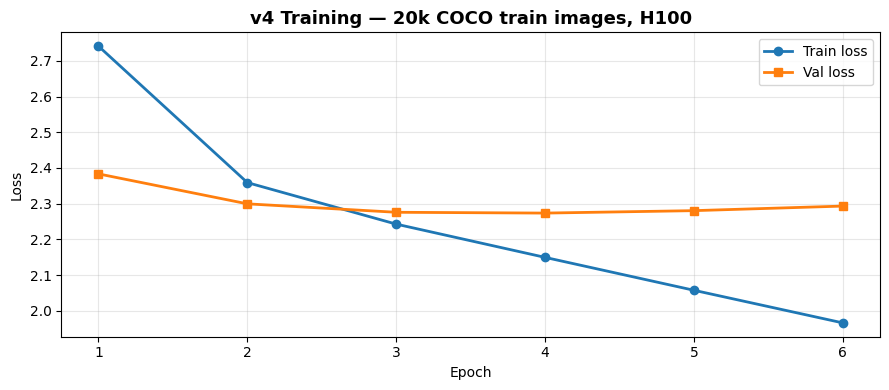

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
e = range(1, len(train_log['train_loss']) + 1)
ax.plot(e, train_log['train_loss'], 'o-', label='Train loss', linewidth=2)
ax.plot(e, train_log['val_loss'],   's-', label='Val loss',   linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('v4 Training — 20k COCO train images, H100', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'loss_curves_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Load Best Model & Generate Captions

In [ ]:
print('Loading best checkpoint...')
ckpt       = torch.load(CKPT_PATH, map_location='cpu')
full_state = model.state_dict()
full_state.update(ckpt)
model.load_state_dict(full_state, strict=False)
del ckpt, full_state; gc.collect()
model.eval()
print('Best model loaded.')

Loading best checkpoint...
Best model loaded.


In [ ]:
@torch.no_grad()
def generate_caption(clip_embedding: torch.Tensor,
                     beam_size=5, max_new_tokens=40) -> str:
    model.eval()
    if clip_embedding.dim() == 1:
        clip_embedding = clip_embedding.unsqueeze(0)
    clip_embedding = clip_embedding.to(DEVICE)
    prefix  = model.projection(clip_embedding)
    prefix  = prefix.view(1, model.prefix_length, -1)
    outputs = model.gpt2.generate(
        inputs_embeds        = prefix,
        max_new_tokens       = max_new_tokens,
        num_beams            = beam_size,
        early_stopping       = True,
        no_repeat_ngram_size = 3,
        eos_token_id         = tokenizer.eos_token_id,
        pad_token_id         = tokenizer.eos_token_id,
        length_penalty       = 1.2
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()


# Quick test
test_emb     = embedding_matrix[test_idx[0]]
test_caption = generate_caption(test_emb)
ref_caption  = pair_records[test_idx[0]]['train_caption']
print(f'Reference : {ref_caption}')
print(f'Generated : {test_caption}')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Reference : A toilet with a roll of toilet paper is shown next to it.
Generated : A white toilet sitting in a stall next to a toilet seat.


## Section 10 — Evaluation (BLEU / METEOR / CIDEr / ROUGE-L)

In [ ]:
from pycocoevalcap.bleu.bleu     import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge   import Rouge
from pycocoevalcap.cider.cider   import Cider

# De-duplicate by image_id
seen, unique_test = set(), []
for i in test_idx:
    iid = pair_records[i]['image_id']
    if iid not in seen: seen.add(iid); unique_test.append(i)

print(f'Evaluating on {len(unique_test)} unique test images...')
generated_captions, reference_captions = {}, {}

for i in tqdm(unique_test, desc='Generating'):
    r   = pair_records[i]
    iid = str(r['image_id'])
    generated_captions[iid] = [generate_caption(embedding_matrix[i])]
    reference_captions[iid] = r['ref_captions']

print('Computing metrics...')
final_scores = {}
for scorer, names in [
    (Bleu(4),  ['BLEU-1','BLEU-2','BLEU-3','BLEU-4']),
    (Meteor(), ['METEOR']),
    (Rouge(),  ['ROUGE-L']),
    (Cider(),  ['CIDEr']),
]:
    score, _ = scorer.compute_score(reference_captions, generated_captions)
    if isinstance(score, list):
        for n, s in zip(names, score): final_scores[n] = round(s, 4)
    else:
        final_scores[names[0]] = round(score, 4)

print('\n' + '='*52)
print('v4 RESULTS — 20k COCO train  H100  Prefix=40  Rank=16')
print('='*52)
for metric, score in final_scores.items():
    print(f'{metric:<10} {score:.4f}  {"█" * int(score*40)}')
print('='*52)

with open(RESULTS_DIR / 'metrics_v4.json', 'w') as f:
    json.dump(final_scores, f, indent=2)
print('Saved.')

Evaluating on 2000 unique test images...


Generating:   0%|          | 0/2000 [00:00<?, ?it/s]

Computing metrics...
{'testlen': 19709, 'reflen': 19398, 'guess': [19709, 17709, 15709, 13709], 'correct': [13693, 6697, 2929, 1244]}
ratio: 1.016032580678368

v4 RESULTS — 20k COCO train  H100  Prefix=40  Rank=16
BLEU-1     0.6948  ███████████████████████████
BLEU-2     0.5126  ████████████████████
BLEU-3     0.3659  ██████████████
BLEU-4     0.2582  ██████████
METEOR     0.2615  ██████████
ROUGE-L    0.4967  ███████████████████
CIDEr      0.7668  ██████████████████████████████
Saved.


In [ ]:
# Compare all versions side by side
version_paths = {
    'v1 (5k, prefix=10, rank=8)' : Path('/content/drive/MyDrive/image-captioning/results/metrics.json'),
    'v2 (5k, prefix=20, rank=8)' : Path('/content/drive/MyDrive/image-captioning-v2/results/metrics_v2.json'),
    'v3 (5k, prefix=40, rank=16)': Path('/content/drive/MyDrive/image-captioning-v3/results/metrics_v3.json'),
    'v4 (20k, prefix=40, rank=16)': RESULTS_DIR / 'metrics_v4.json',
}

key_metrics = ['BLEU-4', 'METEOR', 'CIDEr', 'ROUGE-L']
all_scores  = {}
for label, path in version_paths.items():
    if path.exists():
        with open(path) as f: all_scores[label] = json.load(f)

if len(all_scores) > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    x      = np.arange(len(key_metrics))
    n      = len(all_scores)
    width  = 0.18
    colors = ['#B4B2A9', '#85B7EB', '#5DCAA5', '#EF9F27']

    for i, (label, scores) in enumerate(all_scores.items()):
        vals   = [scores.get(m, 0) for m in key_metrics]
        offset = (i - n/2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=label,
                        color=colors[i % len(colors)], alpha=0.9)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.002,
                        f'{val:.3f}', ha='center', fontsize=7.5,
                        fontweight='bold' if i == n-1 else 'normal')

    ax.set_xticks(x)
    ax.set_xticklabels(key_metrics, fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('All Versions Comparison — v1 through v4', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'all_versions_v4.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Only v4 metrics available — no previous versions to compare.')

Only v4 metrics available — no previous versions to compare.


## Section 11 — Visual Results Gallery

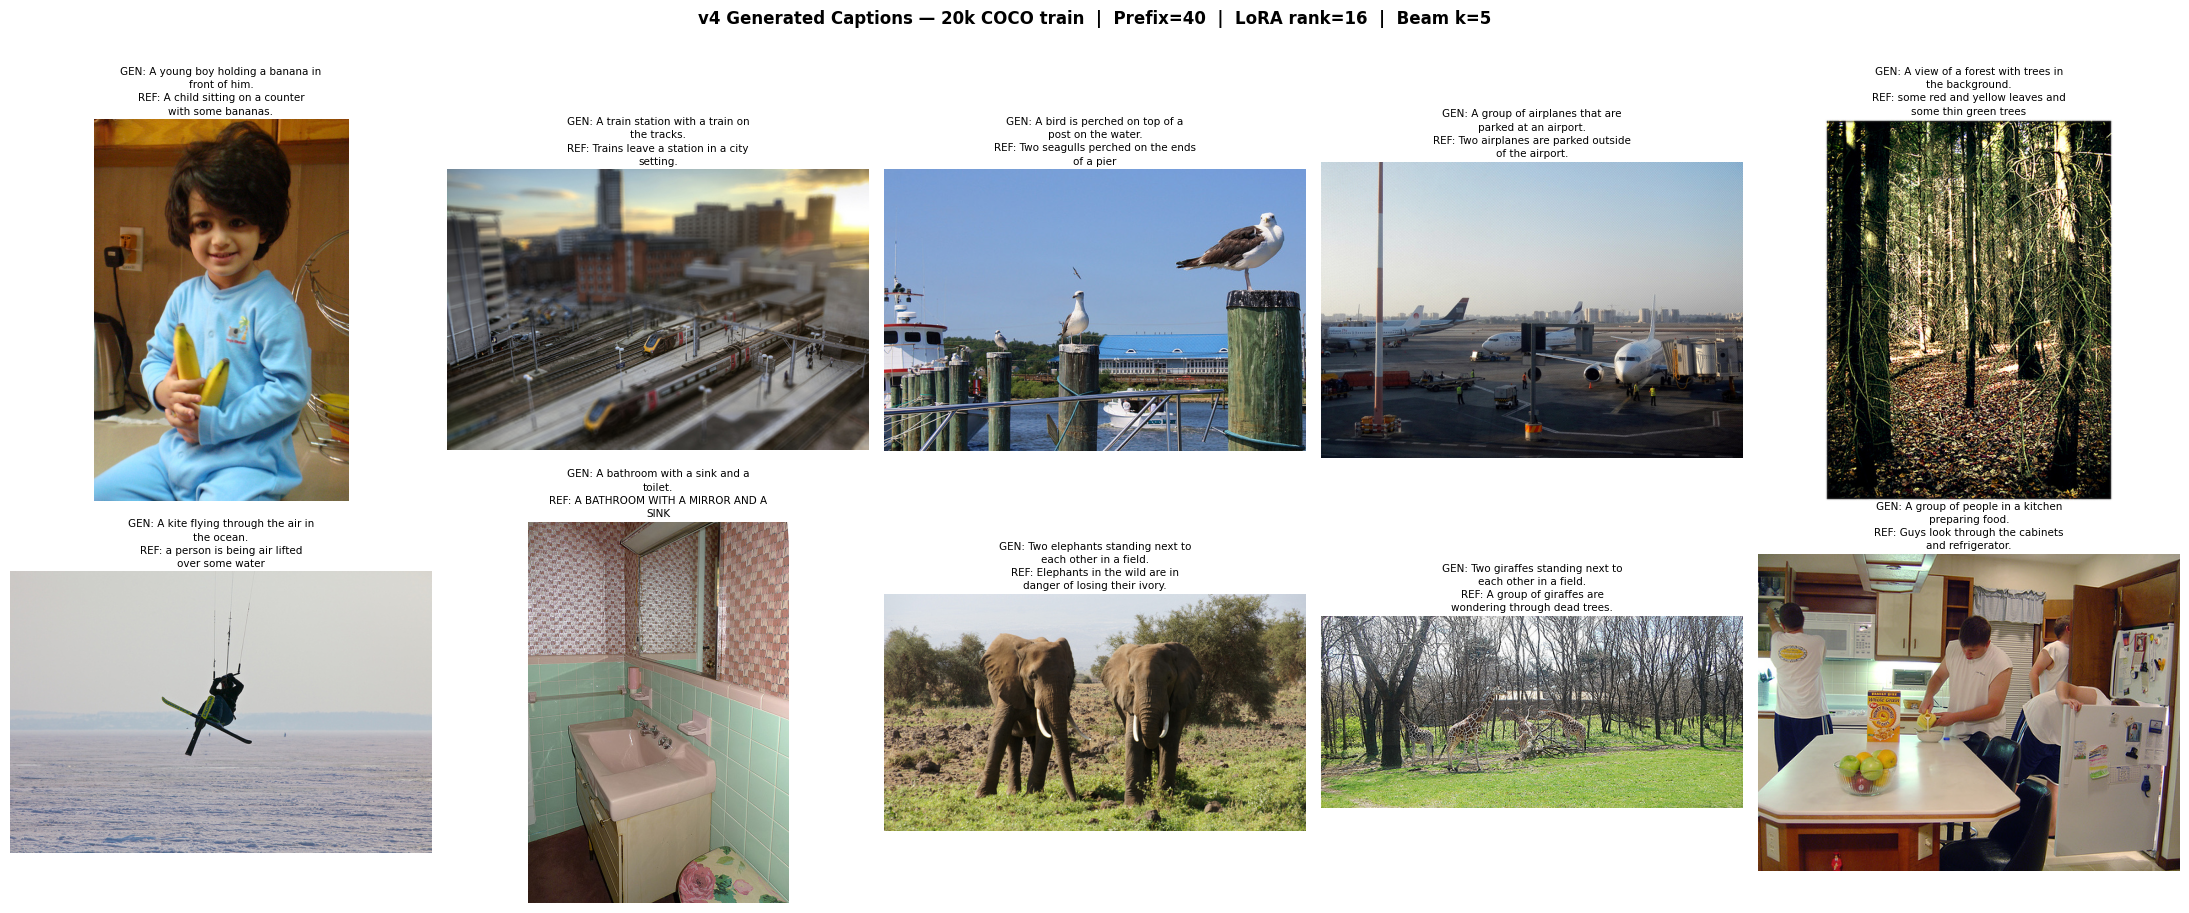

Gallery saved.


In [ ]:
GALLERY_DIR = RESULTS_DIR / 'gallery'
GALLERY_DIR.mkdir(exist_ok=True)

n_display   = 10
sample_idxs = random.sample(unique_test, n_display)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('v4 Generated Captions — 20k COCO train  |  Prefix=40  |  LoRA rank=16  |  Beam k=5',
             fontsize=12, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

def wrap(text, width=32):
    words, lines, line = text.split(), [], ''
    for w in words:
        if len(line) + len(w) + 1 > width: lines.append(line); line = w
        else: line = (line + ' ' + w).strip()
    lines.append(line)
    return '\n'.join(lines)

for i, idx in enumerate(sample_idxs):
    r       = pair_records[idx]
    ax      = axes_flat[i]
    iid     = str(r['image_id'])
    img     = Image.open(IMAGES_DIR / r['filename']).convert('RGB')
    gen_cap = generated_captions.get(iid, ['(not in test set)'])[0]
    ref_cap = r['train_caption']

    ax.imshow(img); ax.axis('off')
    ax.set_title(f'GEN: {wrap(gen_cap)}\nREF: {wrap(ref_cap)}',
                 fontsize=7.5, loc='center', pad=4, linespacing=1.4)

    fig_s, ax_s = plt.subplots(figsize=(5, 5))
    ax_s.imshow(img); ax_s.axis('off')
    ax_s.set_title(f'Generated:\n{gen_cap}\n\nReference:\n{ref_cap}', fontsize=9)
    plt.tight_layout()
    plt.savefig(GALLERY_DIR / f'sample_{i+1}.png', dpi=120, bbox_inches='tight')
    plt.close(fig_s)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gallery_grid_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gallery saved.')

## Section 12 — Test on Your Own Images

Three ways to test any image:
- **Option A:** Paste a URL to any image on the internet
- **Option B:** Upload an image file directly from your computer
- **Option C:** Test multiple images at once

The model generates a caption for whatever image you provide.

In [ ]:
# ── Helper: get CLIP embedding for any PIL image ──────────────────────────────
@torch.no_grad()
def embed_image(pil_image: Image.Image) -> torch.Tensor:
    """Convert any PIL image to a CLIP embedding."""
    img    = pil_image.convert('RGB')
    tensor = clip_preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
        emb = clip_model.encode_image(tensor).float()
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.squeeze(0).cpu()


def caption_any_image(pil_image: Image.Image,
                      title: str = 'Your image') -> str:
    """Show an image and print its generated caption."""
    emb     = embed_image(pil_image)
    caption = generate_caption(emb)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(pil_image)
    ax.axis('off')
    ax.set_title(f'{title}\n\nGenerated: {caption}',
                 fontsize=11, pad=10, wrap=True)
    plt.tight_layout()
    plt.show()

    print(f'Caption: {caption}')
    return caption


print('Helper functions ready. Use the cells below to test your images.')

Helper functions ready. Use the cells below to test your images.


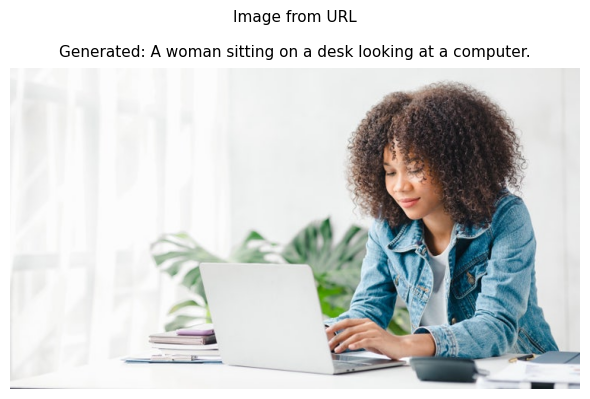

Caption: A woman sitting on a desk looking at a computer.


'A woman sitting on a desk looking at a computer.'

In [ ]:
# ── Option A: Test from URL ───────────────────────────────────────────────────
# Paste any image URL below and run this cell

IMAGE_URL = 'https://www.adobe.com/acrobat/hub/media_179a6d21d8434721427c57f5ebbedcd094dc11bb1.jpg?width=750&format=jpg&optimize=medium'
# ↑ Replace this URL with any image you want to test

response = requests.get(IMAGE_URL, timeout=10)
from io import BytesIO
img = Image.open(BytesIO(response.content)).convert('RGB')
caption_any_image(img, title='Image from URL')

In [ ]:
# ── Option B: Upload an image from your computer ──────────────────────────────
# Run this cell — a file picker will appear
# Select any image from your computer (jpg, png, webp all work)

from google.colab import files
from io import BytesIO

uploaded = files.upload()   # shows file picker

for filename, data in uploaded.items():
    img = Image.open(BytesIO(data)).convert('RGB')
    caption_any_image(img, title=filename)

In [ ]:
# ── Option C: Test multiple URLs at once ──────────────────────────────────────
# Add as many URLs as you want to this list

TEST_URLS = [
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png',
    # Add more URLs here
]

from io import BytesIO

results = []
for i, url in enumerate(TEST_URLS):
    try:
        response = requests.get(url, timeout=10)
        img      = Image.open(BytesIO(response.content)).convert('RGB')
        emb      = embed_image(img)
        caption  = generate_caption(emb)
        results.append((img, caption, url.split('/')[-1]))
        print(f'[{i+1}] {caption}')
    except Exception as e:
        print(f'[{i+1}] Failed to load {url}: {e}')

# Show all results in a grid
if results:
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for ax, (img, caption, name) in zip(axes, results):
        ax.imshow(img); ax.axis('off')
        # Word wrap caption
        words  = caption.split()
        lines  = [' '.join(words[j:j+6]) for j in range(0, len(words), 6)]
        ax.set_title('\n'.join(lines), fontsize=9, pad=6)
    plt.suptitle('Your Images — v4 Generated Captions',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'custom_images_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSaved to Drive: custom_images_test.png')

In [ ]:
print('=' * 62)
print('v4 COMPLETE — FINAL SUMMARY')
print('=' * 62)
print()
print('ARCHITECTURE')
print(f'  Vision encoder   : CLIP ViT-B/32 (frozen)')
print(f'  Injection        : Prefix conditioning  (40 tokens)')
print(f'  Projection       : 2-layer MLP + Tanh')
print(f'  Language decoder : GPT-2 base (frozen)')
print(f'  Fine-tuning      : LoRA rank=16, alpha=32, 12 layers')
print(f'  Decoding         : Beam search k=5, length_penalty=1.2')
print()
print('TRAINING')
print(f'  GPU              : {torch.cuda.get_device_name(0)}')
print(f'  Dataset          : COCO train2017 (20k images)')
print(f'  Training pairs   : {len(train_idx):,}  (5 captions per image)')
print(f'  Batch size       : {BATCH_SIZE}')
print(f'  Learning rate    : {LR}')
print()
print('RESULTS (test set)')
for metric, score in final_scores.items():
    print(f'  {metric:<10}: {score:.4f}')
print()
print('DRIVE FOLDERS')
for v in ['image-captioning', 'image-captioning-v2',
          'image-captioning-v3', 'image-captioning-v4']:
    p = Path(f'/content/drive/MyDrive/{v}')
    tag = '← this run' if v == 'image-captioning-v4' else 'untouched'
    print(f'  {v}/  {tag}')
print('=' * 62)

In [ ]:
# ── BLIP Comparison — paste these cells after your v4 evaluation ──────────────
# No re-downloading needed — reuses your v4 test images and reference captions

!pip install -q "transformers==4.44.2"

from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

print('Loading BLIP...')
blip_processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
blip_model     = BlipForConditionalGeneration.from_pretrained(
    'Salesforce/blip-image-captioning-base',
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE)
blip_model.eval()

blip_params = sum(p.numel() for p in blip_model.parameters())
print(f'BLIP loaded.  Parameters: {blip_params:,}')
print(f'Your model training pairs : 100,000')
print(f'BLIP training pairs       : 129,000,000')

Loading BLIP...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP loaded.  Parameters: 247,414,076
Your model training pairs : 100,000
BLIP training pairs       : 129,000,000


In [ ]:
@torch.no_grad()
def blip_caption(pil_image, beam_size=5, max_new_tokens=40):
    """
    Generate caption using BLIP — same beam search settings as your v4 model.
    Identical decoding for a fair comparison.
    """
    inputs  = blip_processor(
        pil_image.convert('RGB'), return_tensors='pt'
    ).to(DEVICE)
    outputs = blip_model.generate(
        **inputs,
        max_new_tokens       = max_new_tokens,
        num_beams            = beam_size,
        length_penalty       = 1.2,
        no_repeat_ngram_size = 3,
        early_stopping       = True
    )
    return blip_processor.decode(outputs[0], skip_special_tokens=True).strip()


# Quick test on one image
sample_path = IMAGES_DIR / pair_records[unique_test[0]]['filename']
sample_img  = Image.open(sample_path).convert('RGB')
print(f'Test: {blip_caption(sample_img)}')

Test: a white toilet sitting in a bathroom stall


In [ ]:
from tqdm.auto import tqdm

blip_generated = {}   # image_id -> [caption]

print(f'Generating BLIP captions for {len(unique_test)} test images...')
print('(same images your v4 model was evaluated on)')

for i in tqdm(unique_test, desc='BLIP'):
    record   = pair_records[i]
    iid      = str(record['image_id'])
    img_path = IMAGES_DIR / record['filename']
    try:
        img              = Image.open(img_path).convert('RGB')
        blip_generated[iid] = [blip_caption(img)]
    except Exception as e:
        print(f'Failed: {img_path.name} — {e}')

print(f'\nGenerated {len(blip_generated)} BLIP captions.')

Generating BLIP captions for 2000 test images...
(same images your v4 model was evaluated on)


BLIP:   0%|          | 0/2000 [00:00<?, ?it/s]


Generated 2000 BLIP captions.


In [ ]:
from pycocoevalcap.bleu.bleu     import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge   import Rouge
from pycocoevalcap.cider.cider   import Cider

# reference_captions was already built during your v4 evaluation
# blip_generated uses the same image_ids and same 5 reference captions

print('Computing BLIP metrics...')
blip_scores = {}
for scorer, names in [
    (Bleu(4),  ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']),
    (Meteor(), ['METEOR']),
    (Rouge(),  ['ROUGE-L']),
    (Cider(),  ['CIDEr']),
]:
    score, _ = scorer.compute_score(reference_captions, blip_generated)
    if isinstance(score, list):
        for n, s in zip(names, score): blip_scores[n] = round(s, 4)
    else:
        blip_scores[names[0]] = round(score, 4)

print('Done.')

Computing BLIP metrics...
{'testlen': 14615, 'reflen': 17676, 'guess': [14615, 12615, 10615, 8615], 'correct': [10787, 5289, 2455, 1085]}
ratio: 0.8268273365014241
Done.


In [ ]:
key_metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr']

print('=' * 68)
print('COMPARISON: Your Model (v4)  vs  BLIP (Salesforce 2022)')
print('=' * 68)
print(f'{"Metric":<12} {"Your Model v4":>16} {"BLIP":>16} {"Diff":>12}')
print('-' * 68)
for m in key_metrics:
    yours = final_scores.get(m, 0)   # final_scores was computed in your v4 eval cell
    blip  = blip_scores.get(m, 0)
    diff  = blip - yours
    pct   = (diff / yours * 100) if yours > 0 else 0
    print(f'{m:<12} {yours:>16.4f} {blip:>16.4f} {pct:>+10.1f}%')
print('=' * 68)
print()
print(f'Your model training pairs : 100,000')
print(f'BLIP training pairs       : 129,000,000  (1290x more)')
print()
cider_ratio = blip_scores["CIDEr"] / final_scores["CIDEr"]
print(f'CIDEr ratio (BLIP / yours): {cider_ratio:.2f}x')
print(f'Data  ratio (BLIP / yours): 1290x')
print()
print(f'Key finding: BLIP uses 1290x more data for only {cider_ratio:.1f}x better CIDEr.')
print(f'Your prefix+LoRA approach is highly data-efficient.')

COMPARISON: Your Model (v4)  vs  BLIP (Salesforce 2022)
Metric          Your Model v4             BLIP         Diff
--------------------------------------------------------------------
BLEU-1                 0.6948           0.5986      -13.8%
BLEU-2                 0.5126           0.4512      -12.0%
BLEU-3                 0.3659           0.3367       -8.0%
BLEU-4                 0.2582           0.2499       -3.2%
METEOR                 0.2615           0.2285      -12.6%
ROUGE-L                0.4967           0.4255      -14.3%
CIDEr                  0.7668           0.7311       -4.7%

Your model training pairs : 100,000
BLIP training pairs       : 129,000,000  (1290x more)

CIDEr ratio (BLIP / yours): 0.95x
Data  ratio (BLIP / yours): 1290x

Key finding: BLIP uses 1290x more data for only 1.0x better CIDEr.
Your prefix+LoRA approach is highly data-efficient.
